# Mohr-Coulomb Validation — Embedded Crack with Projected Radau Contact

Biaxial compression on a unit square with an embedded (non-through) crack.
The bulk poro-elastodynamic FEM assembly is kept intact; projected Radau
handles the nonsmooth crack contact in nodal traction units.


## 1. Imports

In [1]:
import os
import time
os.environ.setdefault('OMP_NUM_THREADS', '4')

import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt

from skfem.models.elasticity import lame_parameters

from poroelasticity import CGPoroelastostatics, CrackMeshBuilder
from poroelasticity.cg_dashboard import CGPoroelasticDashboard

import solve_nivp
from solve_nivp.projected_radau_contact import build_projected_radau_contact

print(f"solve_nivp version: {getattr(solve_nivp, '__version__', 'dev')}")
print('Imports OK')


solve_nivp version: dev
Imports OK


## 2. Configuration

`ALPHA_BIOT = 0` decouples fluid and solid — pure elastodynamics.  High bulk viscous
damping (`BULK_MU_V`, `BULK_LAM_V`) overdamps the system so the Radau IIA time-stepping
is effectively quasi-static.  The crack is embedded at `(0.5, 0.5)` with length 0.4,
well inside the unit square.

In [ ]:
NU          = 0.25
G_SHEAR     = 22.0e3                # MPa
E_YOUNG     = 2.0 * G_SHEAR * (1.0 + NU)
ALPHA_BIOT  = 0.0                   # set > 0 to activate Biot pore-pressure coupling
BETA_FLUID  = 8.5e-5
ETA_FLUID   = 2.0e-18 / 3600.0
K_PERM      = 1.0e-15 * 1.0e-6
DENSITY     = 1.0
BULK_MU_V   = 1.0e3*0
BULK_LAM_V  = 1.0e3*0
SCALE_L     = 1.0
SCALE_EPS   = 1.0e-3

XMIN, XMAX = 0.0, 10.0
YMIN, YMAX = 0.0, 10.0
N_ELEM     = 20

CRACK_X0     = 10.0
CRACK_Y0     = 10.0
CRACK_LENGTH = 4.
CONFORMING_CRACK_MESH = True

SIGMA_RIGHT = 10.0                  # MPa, compression positive
SIGMA_TOP   = 30.0
P_GAMMA_BACKGROUND_MPA = 0.0        # constant crack pore pressure added to the effective offset

MU = 0.3
PROJECTED_CONTACT_LAW = 'fischer'
# Backend note: 'force' means the reported contact state is divided by h
# before storage.  In this embedded-crack notebook that corresponds to the
# non-impulse effective traction measure used by the Mohr-Coulomb checks;
# interface quadrature weights remain inside B_c.
REPORTED_REACTION_MODE = 'force'

TMAX    = 5.0
H_FIXED = 0.1

# Toggle this to compare the fixed-step solve with the embedded Radau IIA
# adaptive controller used in the porodynamics friction notebook.
USE_ADAPTIVE_SLIDING = False
ADAPTIVE_SLIDING_RTOL = 5.0e-2
ADAPTIVE_SLIDING_ATOL = 1.0e-3
ADAPTIVE_SLIDING_H_MIN = 1.0e-5
ADAPTIVE_SLIDING_H_MAX = 0.8

LAM, MU_LAME = lame_parameters(E_YOUNG, NU)
PARAMS = (MU_LAME, LAM, ALPHA_BIOT, BETA_FLUID, K_PERM / ETA_FLUID)

if ALPHA_BIOT != 0.0:
    Mmod = ALPHA_BIOT**2 / BETA_FLUID
    P_scale = ALPHA_BIOT * SCALE_EPS / BETA_FLUID
else:
    Mmod = LAM + 2 * MU_LAME
    P_scale = 1.0
Sigma_scale = Mmod * SCALE_EPS

S1 = max(SIGMA_RIGHT, SIGMA_TOP)
S3 = min(SIGMA_RIGHT, SIGMA_TOP)

def solver_alpha_d(poro_obj=None):
    if poro_obj is not None and hasattr(poro_obj, 'alpha_d'):
        return float(poro_obj.alpha_d)
    return 1.0 if ALPHA_BIOT != 0.0 else 0.0

def solver_sigma_scale(poro_obj=None):
    if poro_obj is not None and hasattr(poro_obj, 'Sigma_scale'):
        return float(poro_obj.Sigma_scale)
    return float(Sigma_scale)

def solver_pressure_scale(poro_obj=None):
    if poro_obj is not None and hasattr(poro_obj, 'P_scale'):
        return float(poro_obj.P_scale)
    return float(P_scale)

def effective_normal_stress_mpa(sigma_total_mpa, p_gamma_mpa=P_GAMMA_BACKGROUND_MPA):
    return np.asarray(sigma_total_mpa, dtype=float) + ALPHA_BIOT * float(p_gamma_mpa)

def _line_transfer_matrix(source_coords, target_coords):
    source_coords = np.asarray(source_coords, dtype=float)
    target_coords = np.asarray(target_coords, dtype=float)
    if source_coords.ndim != 2 or target_coords.ndim != 2:
        raise ValueError('Interface coordinates must have shape (dim, n).')
    n_src = int(source_coords.shape[1])
    n_tgt = int(target_coords.shape[1])
    if n_src == 0:
        raise ValueError('Cannot build a pressure trace transfer from zero source nodes.')
    if n_tgt == 0:
        return sp.csr_matrix((0, n_src))
    if n_src == n_tgt and np.allclose(source_coords, target_coords, rtol=1e-10, atol=1e-12):
        return sp.eye(n_tgt, n_src, format='csr')
    if n_src == 1:
        return sp.csr_matrix((np.ones(n_tgt), (np.arange(n_tgt), np.zeros(n_tgt, dtype=int))),
                             shape=(n_tgt, n_src))

    all_coords = np.column_stack([source_coords, target_coords])
    centered = all_coords - all_coords.mean(axis=1, keepdims=True)
    axis = np.linalg.svd(centered, full_matrices=False)[0][:, 0]
    s_src = axis @ source_coords
    s_tgt = axis @ target_coords

    span = max(float(np.ptp(s_src)), float(np.ptp(s_tgt)), 1.0)
    tol = 1e-12 * span
    order = np.argsort(s_src)
    groups = []
    group_s = []
    for col in order:
        sval = float(s_src[col])
        if group_s and abs(sval - group_s[-1]) <= tol:
            groups[-1].append(int(col))
            group_s[-1] = 0.5 * (group_s[-1] + sval)
        else:
            groups.append([int(col)])
            group_s.append(sval)
    group_s = np.asarray(group_s, dtype=float)

    rows, cols, data = [], [], []
    def add_group(row, group_idx, weight):
        group = groups[int(group_idx)]
        w = float(weight) / len(group)
        for col in group:
            rows.append(row)
            cols.append(col)
            data.append(w)

    if group_s.size == 1:
        for row in range(n_tgt):
            add_group(row, 0, 1.0)
    else:
        for row, sval in enumerate(s_tgt):
            sval = float(sval)
            if sval <= group_s[0] + tol:
                add_group(row, 0, 1.0)
            elif sval >= group_s[-1] - tol:
                add_group(row, group_s.size - 1, 1.0)
            else:
                right = int(np.searchsorted(group_s, sval, side='right'))
                left = right - 1
                denom = group_s[right] - group_s[left]
                frac = 0.0 if abs(denom) <= tol else (sval - group_s[left]) / denom
                add_group(row, left, 1.0 - frac)
                add_group(row, right, frac)
    return sp.csr_matrix((data, (rows, cols)), shape=(n_tgt, n_src))

def _avg_pressure_trace_coords(poro_obj, info):
    n_intf_p = int(info['n_intf_p'])
    off_avgp = int(info['off_avgp'])
    dim = int(getattr(poro_obj, 'dim', 2))
    basis_coords = np.asarray(poro_obj.basis_p.doflocs[:dim, :], dtype=float)
    coords = np.full((dim, n_intf_p), np.nan, dtype=float)

    T_inv = getattr(poro_obj, '_T_inv', None)
    if T_inv is not None and n_intf_p:
        T_inv_csc = T_inv.tocsc()
        n_p = int(poro_obj.basis_p.N)
        for j, col in enumerate(off_avgp + np.arange(n_intf_p)):
            start, end = T_inv_csc.indptr[col], T_inv_csc.indptr[col + 1]
            rows = T_inv_csc.indices[start:end]
            vals = np.abs(T_inv_csc.data[start:end])
            mask = rows < n_p
            rows = rows[mask]
            vals = vals[mask]
            if rows.size and vals.sum() > 0.0:
                coords[:, j] = (basis_coords[:, rows] @ vals) / vals.sum()

    bad = ~np.isfinite(coords[0, :])
    dofs = np.asarray(info.get('dofs_p_plus', []), dtype=int)
    if np.any(bad) and dofs.size >= n_intf_p:
        fallback = basis_coords[:, dofs[:n_intf_p]]
        coords[:, bad] = fallback[:, bad]
    if np.any(~np.isfinite(coords)):
        raise RuntimeError('Could not recover coordinates for all average-pressure trace DOFs.')
    return coords

def _contact_trace_coords(poro_obj, n_contact):
    dim = int(getattr(poro_obj, 'dim', 2))
    intf = getattr(poro_obj, '_nodal_interface_info', None) or {}
    coords = np.asarray(intf.get('lambda_coords', np.zeros((dim, 0))), dtype=float)
    if coords.ndim == 2 and coords.shape[1] >= n_contact:
        return coords[:dim, :n_contact]
    info = poro_obj._transform_info
    dofs = np.asarray(info.get('dofs_p_plus', []), dtype=int)
    if dofs.size >= n_contact:
        return np.asarray(poro_obj.basis_p.doflocs[:dim, dofs[:n_contact]], dtype=float)
    raise RuntimeError('Could not recover coordinates for all contact pressure trace nodes.')

def build_pressure_trace_extract(poro_obj, n_contact, n_state, *, label=''):
    info = poro_obj._transform_info
    n_intf_p = int(info['n_intf_p'])
    off_avgp = int(info['off_avgp'])
    if n_intf_p <= 0:
        raise ValueError(f'{label}: no pressure trace DOFs are available on the crack interface.')
    selector = sp.csr_matrix(
        (np.ones(n_intf_p), (np.arange(n_intf_p), off_avgp + np.arange(n_intf_p))),
        shape=(n_intf_p, n_state),
    )
    source_coords = _avg_pressure_trace_coords(poro_obj, info)
    target_coords = _contact_trace_coords(poro_obj, n_contact)
    transfer = _line_transfer_matrix(source_coords, target_coords)
    extract = (transfer @ selector).tocsr()
    extract.eliminate_zeros()
    return extract, {
        'n_intf_p': n_intf_p,
        'transfer_nnz': int(transfer.nnz),
        'source_coords': source_coords,
        'target_coords': target_coords,
    }

def audit_pressure_normal_coupling(label, poro_obj, B_n, C_p_gamma, pressure_normal_correction,
                                   vel_contact_extract, omega_n, n_state):
    alpha_d = solver_alpha_d(poro_obj)
    probe = np.sin(0.37 * np.arange(n_state)) + 0.25 * np.cos(0.11 * np.arange(n_state))
    direct = pressure_normal_correction @ probe
    split = -alpha_d * (B_n @ (C_p_gamma @ probe))
    split_err = float(np.linalg.norm(direct - split, ord=np.inf))
    split_ref = max(1.0, float(np.linalg.norm(split, ord=np.inf)))

    W_n = (vel_contact_extract[0::2, :] @ B_n).toarray()
    W_ref = np.diag(np.asarray(omega_n, dtype=float))
    weight_err = float(np.linalg.norm(W_n - W_ref, ord=np.inf))
    weight_ref = max(1.0, float(np.linalg.norm(W_ref, ord=np.inf)))

    print(f"{label} pressure trace: C_pΓ shape={C_p_gamma.shape}, nnz={C_p_gamma.nnz}, "
          f"alpha_d={alpha_d:.3g}, pressure correction nnz={pressure_normal_correction.nnz}")
    print(f"{label} pressure-normal audit: split_rel={split_err/split_ref:.3e}, "
          f"normal_weight_rel={weight_err/weight_ref:.3e}")
    assert split_err <= 1e-11 * split_ref
    assert weight_err <= 1e-10 * weight_ref

print(f"Domain:  [{XMIN},{XMAX}] × [{YMIN},{YMAX}],  N_ELEM = {N_ELEM}")
print(f"Crack:   centre=({CRACK_X0},{CRACK_Y0}), length={CRACK_LENGTH}, conforming={CONFORMING_CRACK_MESH}")
print(f"Loading: σ_right={SIGMA_RIGHT}, σ_top={SIGMA_TOP}  →  σ₁={S1}, σ₃={S3}")
print(f"Friction: μ = {MU}")
print(f"Biot:    α={ALPHA_BIOT}, pΓ,background={P_GAMMA_BACKGROUND_MPA} MPa")
print(f"Damping: bulk_mu_v={BULK_MU_V:.1e}, bulk_lam_v={BULK_LAM_V:.1e}")
print(f"Nondim:  Mmod={Mmod:.0f} MPa, P_scale={P_scale:.3g} MPa, Σ_scale={Sigma_scale:.3g} MPa")
print(f"Time:    tmax={TMAX}, h={H_FIXED}")

Domain:  [0.0,10.0] × [0.0,10.0],  N_ELEM = 20
Crack:   centre=(5.0,5.0), length=4.0, conforming=True
Loading: σ_right=10.0, σ_top=30.0  →  σ₁=30.0, σ₃=10.0
Friction: μ = 0.3
Biot:    α=0.0, pΓ,background=0.0 MPa
Damping: bulk_mu_v=0.0e+00, bulk_lam_v=0.0e+00
Nondim:  Mmod=66000 MPa, P_scale=1 MPa, Σ_scale=66 MPa
Time:    tmax=5.0, h=0.1


## 3. Analytical Mohr-Coulomb

On a plane at angle θ from σ₁ (compression positive):

$$\sigma_N(\theta) = \frac{\sigma_1 + \sigma_3}{2} + \frac{\sigma_1 - \sigma_3}{2}\cos 2\theta, \qquad
\tau(\theta) = \frac{\sigma_1 - \sigma_3}{2}\sin 2\theta$$

Coulomb failure (cohesionless): $|\tau| = \mu\,\sigma_N$.

The **failure plane angle** $\theta_{\mathrm{crit}} = \tfrac{1}{2}\arctan(1/\mu)$ maximises
the ratio $|\tau|/\mu\sigma_N$ over all orientations.  When the Mohr circle extends past
the Coulomb envelope — as it does here — there is a **range** of orientations
$[\theta_{\mathrm{onset}},\,\theta_{\mathrm{upper}}]$ where $|\tau| > \mu\sigma_N$.

**Angle convention:** `CrackMeshBuilder` parameterizes `crack_theta` as the angle of the
crack *line* measured counter-clockwise from the y-axis.  With σ₁ vertical, a Mohr angle
θ from σ₁ corresponds to `crack_theta = π/2 − θ`.

In [45]:
phi = np.arctan(MU)
theta_crit = 0.5 * np.arctan(1.0 / MU)

a_mc = (S1 - S3) / 2
R_mc = a_mc * np.sqrt(1 + MU**2)
sin_arg = MU * (S1 + S3) / (2 * R_mc)
theta_onset = 0.5 * (phi + np.arcsin(sin_arg))
theta_upper = 0.5 * (phi + np.pi - np.arcsin(sin_arg))

THETA_LOCKED  = np.radians(20.0)
THETA_SLIDING = np.radians(45.0)

def mohr_tractions(theta):
    sigma_N = (S1 + S3) / 2 + (S1 - S3) / 2 * np.cos(2 * theta)
    tau     = (S1 - S3) / 2 * np.sin(2 * theta)
    return sigma_N, tau

sN_locked,  tau_locked  = mohr_tractions(THETA_LOCKED)
sN_sliding, tau_sliding = mohr_tractions(THETA_SLIDING)

CRACK_THETA_LOCKED  = np.pi / 2 - THETA_LOCKED
CRACK_THETA_SLIDING = np.pi / 2 - THETA_SLIDING

print(f"θ_crit  = {np.degrees(theta_crit):.2f}° (failure plane angle)")
print(f"Failure zone: [{np.degrees(theta_onset):.2f}°, {np.degrees(theta_upper):.2f}°]")
print(f"φ = arctan(μ) = {np.degrees(phi):.2f}°")
print()
print(f"Locked test  (θ = {np.degrees(THETA_LOCKED):.0f}° < θ_onset = {np.degrees(theta_onset):.1f}°):")
print(f"  σ_N = {sN_locked:.2f},  τ = {tau_locked:.2f},  μσ_N = {MU*sN_locked:.2f}")
print(f"  |τ|/μσ_N = {abs(tau_locked)/(MU*sN_locked):.4f}  (< 1 → locked)")
print(f"  crack_theta = {np.degrees(CRACK_THETA_LOCKED):.1f}°")
print()
print(f"Sliding test (θ = {np.degrees(THETA_SLIDING):.0f}° ∈ failure zone):")
print(f"  σ_N = {sN_sliding:.2f},  τ = {tau_sliding:.2f},  μσ_N = {MU*sN_sliding:.2f}")
print(f"  |τ|/μσ_N = {abs(tau_sliding)/(MU*sN_sliding):.4f}  (> 1 → sliding)")
print(f"  crack_theta = {np.degrees(CRACK_THETA_SLIDING):.1f}°")

θ_crit  = 36.65° (failure plane angle)
Failure zone: [25.89°, 80.81°]
φ = arctan(μ) = 16.70°

Locked test  (θ = 20° < θ_onset = 25.9°):
  σ_N = 27.66,  τ = 6.43,  μσ_N = 8.30
  |τ|/μσ_N = 0.7746  (< 1 → locked)
  crack_theta = 70.0°

Sliding test (θ = 45° ∈ failure zone):
  σ_N = 20.00,  τ = 10.00,  μσ_N = 6.00
  |τ|/μσ_N = 1.6667  (> 1 → sliding)
  crack_theta = 45.0°


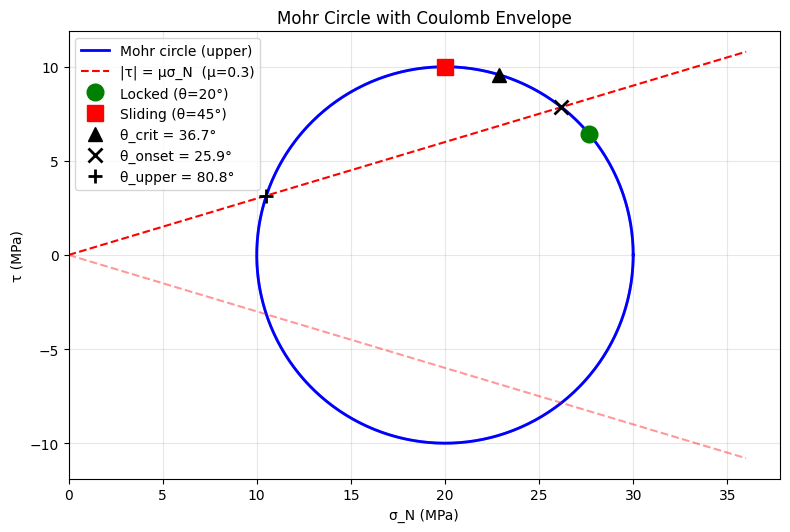

In [46]:
fig, ax = plt.subplots(figsize=(8, 6))

theta_range = np.linspace(0, np.pi, 300)
sN_range, tau_range = mohr_tractions(theta_range)
ax.plot(sN_range, tau_range, 'b-', lw=2, label='Mohr circle (upper)')
ax.plot(sN_range, -tau_range, 'b-', lw=2, alpha=0.4)

sN_env = np.linspace(0, S1 * 1.2, 100)
ax.plot(sN_env, MU * sN_env, 'r--', lw=1.5, label=f'|τ| = μσ_N  (μ={MU})')
ax.plot(sN_env, -MU * sN_env, 'r--', lw=1.5, alpha=0.4)

ax.plot(sN_locked, tau_locked, 'go', ms=12, zorder=5,
        label=f'Locked (θ={np.degrees(THETA_LOCKED):.0f}°)')
ax.plot(sN_sliding, tau_sliding, 'rs', ms=12, zorder=5,
        label=f'Sliding (θ={np.degrees(THETA_SLIDING):.0f}°)')

sN_crit, tau_crit = mohr_tractions(theta_crit)
ax.plot(sN_crit, tau_crit, 'k^', ms=10, zorder=5,
        label=f'θ_crit = {np.degrees(theta_crit):.1f}°')

sN_on, tau_on = mohr_tractions(theta_onset)
sN_up, tau_up = mohr_tractions(theta_upper)
ax.plot(sN_on, tau_on, 'kx', ms=10, mew=2, zorder=5,
        label=f'θ_onset = {np.degrees(theta_onset):.1f}°')
ax.plot(sN_up, tau_up, 'k+', ms=10, mew=2, zorder=5,
        label=f'θ_upper = {np.degrees(theta_upper):.1f}°')

ax.set_xlabel('σ_N (MPa)')
ax.set_ylabel('τ (MPa)')
ax.set_title('Mohr Circle with Coulomb Envelope')
ax.legend(loc='upper left')
ax.set_aspect('equal')
ax.grid(alpha=0.3)
ax.set_xlim(left=0)
plt.tight_layout()
plt.show()

## 4. Build Crack Mesh (Locked Test, θ = 20°)


In [47]:
builder = CrackMeshBuilder(
    XMIN, XMAX, YMIN, YMAX, N_ELEM,
    crack_theta=CRACK_THETA_LOCKED,
    crack_x0=CRACK_X0, crack_y0=CRACK_Y0,
    crack_length=CRACK_LENGTH,
    element_type='tri', conforming=CONFORMING_CRACK_MESH,
    verbose=True,
)
mesh, el_p, el_u, crack, h_mesh = builder.build()
print(f"h ≈ {h_mesh:.4f},  elements = {mesh.nelements},  vertices = {mesh.p.shape[1]}")


Conforming tri mesh: 1032 elements, h=0.5000
[RobustCrackGenerator] Conforming shortcut: 8 crack-aligned facets found — using directly
[RobustCrackGenerator] Timing breakdown:
    setup                              6.5 ms
    conforming_check                  12.2 ms
    find_facets_intersected            0.0 ms
    find_elements_intersected          0.0 ms
    get_candidate_facets               0.0 ms
    compute_metrics                    0.0 ms
    path_selection                     0.0 ms
    TOTAL                             18.8 ms
[RobustCrackGenerator] Surrogate facets: 8
  Alignment: mean=1.000, min=1.000
  |δ|/h:    mean=0.000, max=0.000

Mesh: 557 vertices, 1032 elements
Crack: 8 surrogate facets
h = 0.5
h ≈ 0.5000,  elements = 1032,  vertices = 557


## 5. Assemble CG Solver

`crack_law='nonsmooth'` sets K = I (pure displacement-jump evaluator).
`rotate_crack_to_nt=True` separates normal and tangential DOFs at the crack interface.
Roller BCs: left (v₁ = 0), bottom (v₂ = 0).  No traction BCs — the entire background
stress is carried by s0/w0 offsets.

In [ ]:
bc = {
    'v1': {'left': 0.0},
    'v2': {'bottom': 0.0},
    'dp_rate': {'left': 0.0, 'right': 0.0, 'top': 0.0, 'bottom': 0.0},
}

poro = CGPoroelastostatics(
    mesh=mesh,
    element_p=el_p,
    element_u=el_u,
    params=PARAMS,
    crack=crack,
    intorder=6,
    scales=(SCALE_L, SCALE_EPS),
    bc=bc,
    P_scale=None,
    verbose=True,
    free_memory=False,
    enforcement_type='nodal',
    apply_transform=True,
    include_taylor=True,
    include_hessian=False,
    include_sbm=True,
    density=DENSITY,
    crack_law='nonsmooth',
    rotate_crack_to_nt=True,
    bulk_viscosity={'mu_v': BULK_MU_V, 'lam_v': BULK_LAM_V},
)

print(f"ndofs = {poro.ndofs}")
print(f"  Np = {poro.basis_p.N},  Nu = {poro.basis_u.N}")
print(f"  n_lambda_q = {poro.n_lambda_q},  n_lambda_sigma = {poro.n_lambda_sigma}")
print(f"  crack_law = nonsmooth,  rotated_to_nt = {poro._transform_info.get('rotated_to_nt')}")

Mesh split along crack:
  Original: 557 vertices, 1032 elements
  Split: 564 vertices, 1032 elements
  Crack facets: 8 plus, 8 minus
  Projected 0 / 32 QPs with flipped normals for basis <skfem FacetBasis(MeshTri1, ElementTriP1) object>
  Number of elements: 8
  Number of DOFs: 564
  Size: 2304 B
  Projected 0 / 32 QPs with flipped normals for basis <poroelasticity.cg_crack_assembler.FlippedNormalBasis object at 0x77d5596582d0>
  Projected 0 / 32 QPs with flipped normals for basis <skfem FacetBasis(MeshTri1, ElementVector) object>
  Number of elements: 8
  Number of DOFs: 3192
  Size: 12288 B
  Projected 0 / 32 QPs with flipped normals for basis <poroelasticity.cg_crack_assembler.FlippedNormalBasis object at 0x77d55965a3d0>
SBM geometry cache: 128 QPs pre-computed in 1.1 ms
Crack interface assembled (Spring law + SBM corrections):
  Robin T = 1.00e+02 (dimensionless: 5.90e-03)
  Spring k_n = None (dimensionless: 1.00e+00)
  Spring k_t = None (dimensionless: 1.00e+00)
  Enforcement type

## 6. Projection and Dynamic System

`strip_multiplier_dynamics()` zeros the multiplier rows of `M` so the algebraic
projection owns them.  `build_projection()` builds the constraint projection.
`build_first_order_dynamic_system()` lifts to descriptor form `A_dyn · ẋ = rhs(t, x)`.

In [49]:
poro.strip_multiplier_dynamics()
projection, meta = poro.build_projection()

dyn = poro.build_first_order_dynamic_system(meta, density=DENSITY)

A_dyn          = dyn['A']
rhs_dyn        = dyn['rhs']
rhs_jac_dyn    = dyn['rhs_jac']
velocity_slice = dyn['velocity_slice']
n_base         = dyn['n_base']
comp_slices    = dyn['component_slices']
nl_atol_dyn    = dyn['nl_atol_per_block']

Np = poro.basis_p.N
Nu = poro.basis_u.N

print(f"n_base = {n_base},  |x| = {A_dyn.shape[0]},  nnz(A_dyn) = {A_dyn.nnz}")
print(f"velocity_slice = {velocity_slice}")
print(f"component_slices: {len(comp_slices)} blocks")

build_projection():
  Flux constraint:     C_q shape=(14, 3756)
  Traction constraint: C_s shape=(28, 3756)
  Projection type:     AlgebraicConstraintProjection
  Component slices:    13 blocks
n_base = 3798,  |x| = 6990,  nnz(A_dyn) = 28644
velocity_slice = slice(3798, np.int32(6990), None)
component_slices: 18 blocks


### 6a. Descriptor Pencil Diagnostics

In [50]:
A_csr = A_dyn.tocsr()
J_csr = rhs_jac_dyn(0.0, np.zeros(A_dyn.shape[0])).tocsr()

row_p   = slice(0, Np)
row_u   = slice(Np, Np + Nu)
row_lam = slice(Np + Nu, n_base)
row_mom = slice(n_base, n_base + Nu)

def fro(block):
    return float(sp.linalg.norm(block, 'fro')) if block.nnz else 0.0

print("=== A_dyn block norms (descriptor mass) ===")
print(f"  ||A[p, z]||   = {fro(A_csr[row_p, :n_base]):.3e}")
print(f"  ||A[kin, z]||  = {fro(A_csr[row_u, :n_base]):.3e}")
print(f"  ||A[lam, :]||  = {fro(A_csr[row_lam, :]):.3e}  (expect 0 — stripped)")
print(f"  ||A[mom, v]||  = {fro(A_csr[row_mom, n_base:]):.3e}  (FE inertia)")
print()
print("=== J_dyn block norms (RHS Jacobian) ===")
print(f"  ||J[mom, z]||  = {fro(J_csr[row_mom, :n_base]):.3e}  (stiffness)")
print(f"  ||J[mom, v]||  = {fro(J_csr[row_mom, n_base:]):.3e}  (damping)")

=== A_dyn block norms (descriptor mass) ===
  ||A[p, z]||   = 9.240e+00
  ||A[kin, z]||  = 5.650e+01
  ||A[lam, :]||  = 0.000e+00  (expect 0 — stripped)
  ||A[mom, v]||  = 3.943e+00  (FE inertia)

=== J_dyn block norms (RHS Jacobian) ===
  ||J[mom, z]||  = 2.438e+02  (stiffness)
  ||J[mom, v]||  = 6.481e+00  (damping)


## 7. Projected Radau Contact Wiring

Build extraction matrices and traction coupling directly from `_transform_info` offsets.
With `rotate_crack_to_nt=True`, the transformed state exposes `[[u_n]]` and `[[u_t]]`
as contiguous blocks at known offsets.

- `C_extract` selects displacement jumps `[[u_n]], [[u_t]]` from the dynamic state.
- `D_extract` selects velocity jumps `[[v_n]], [[v_t]]` from the explicit velocity block.
- `B` is the weak-form traction distribution from the transformed `[[λ_σ]]` columns.

The contact solver receives effective nodal tractions.  Interface quadrature weights stay
inside `B`; Mohr offsets are therefore passed as pure nodal tractions, not multiplied by
`omega`.  The Biot pressure part of the normal total traction is split into the smooth
RHS as `-α B_n C_{p,Γ} x`, so mechanics still receives total traction while the cone sees
effective normal traction.


In [51]:

info = poro._transform_info
n_c  = int(poro.n_lambda_q)
dim  = int(poro.dim)

lam_s_sl = meta['lam_s_sl']

off_jmpu  = info['off_jmpu']
n_iu      = info['n_intf_u']
off_jmpls = info['off_jmpls']
n_lsig    = info['n_lam_sig']

# With rotate_crack_to_nt: [[u_n]](n_c) then [[u_t]](n_c)
jmpu_n_indices = np.arange(off_jmpu, off_jmpu + n_c)
jmpu_t_indices = np.arange(off_jmpu + n_c, off_jmpu + n_iu)
jmpu_all = np.concatenate([jmpu_n_indices, jmpu_t_indices])

jmpls_cols = np.arange(off_jmpls, off_jmpls + n_lsig)

print(f"Interface nodes:  n_c = {n_c}")
print(f"[[u_n]] indices:  {jmpu_n_indices[0]}..{jmpu_n_indices[-1]}")
print(f"[[u_t]] indices:  {jmpu_t_indices[0]}..{jmpu_t_indices[-1]}")
print(f"[[λ_σ]] columns:  {jmpls_cols[0]}..{jmpls_cols[-1]}")

T_u_mat = dyn['T_u']
u_idx   = dyn['u_state_indices']
jmpu_local = np.searchsorted(u_idx, jmpu_all)
assert np.all(u_idx[jmpu_local] == jmpu_all), "[[u]] DOFs not found in u_state"
D = T_u_mat[jmpu_local, :].tocsr()

R_v = dyn.get('R_v')
A_csr = poro.A.tocsr()
B_u = (A_csr[Np:Np + Nu, :][:, jmpls_cols]).tocsr()
if R_v is not None:
    B_u = (R_v @ B_u).tocsr()

dirichlet_local = np.array(
    [d - Np for d in np.asarray(getattr(poro, '_dirichlet_dof_set', []), dtype=int)
     if Np <= d < Np + Nu],
    dtype=int,
)
if dirichlet_local.size:
    B_u = B_u.tolil()
    B_u[dirichlet_local, :] = 0.0
    B_u = B_u.tocsr()

scale = h_mesh / 2.0
err_wc = sp.linalg.norm(B_u - scale * D.T) / sp.linalg.norm(B_u)
print(f"\nUniform-weight reference ||B - (h/2)D^T|| / ||B|| = {err_wc:.2e}")
print("  Exact contact weights are checked below through D_contact @ B.")

# Projected Radau reactions are ordered per contact block:
# [r_n0, r_t0, r_n1, r_t1, ...].  The transformed λ jump columns are
# grouped [all σ_n, all τ], so permute B into contact-block order.
perm = [idx for k in range(n_c) for idx in (k, n_c + k)]
B_u_perm = B_u[:, perm].tocsr()
reaction_rows = np.array([row for k in range(n_c) for row in (k, n_c + k)], dtype=int)

contacts = [
    {
        'vel_normal_idx': k,
        'vel_tangential_idx': [n_c + k],
        'mu': MU,
        'e': 0.0,
    }
    for k in range(n_c)
]

print(f"\nContact blocks: {len(contacts)}")


Interface nodes:  n_c = 7
[[u_n]] indices:  3742..3748
[[u_t]] indices:  3749..3755
[[λ_σ]] columns:  3784..3797

Uniform-weight reference ||B - (h/2)D^T|| / ||B|| = 9.94e-16
  Exact contact weights are checked below through D_contact @ B.

Contact blocks: 7


In [52]:
# Build first-order dynamic contact matrices in the augmented physical state y=[z; v].
n_phys_locked = A_dyn.shape[0]
n_aug_phys = n_phys_locked
n_vel = n_aug_phys - n_base
n_extract = 2 * n_c

# Gap rows are grouped [all [[u_n]], all [[u_t]]] in the transformed base state.
gap_extract_dyn = sp.csr_matrix(
    (np.ones(n_extract), (np.arange(n_extract), jmpu_all)),
    shape=(n_extract, n_aug_phys),
)

# Velocity rows use the explicit velocity block returned by build_first_order_dynamic_system.
vel_extract_dyn = sp.hstack(
    [sp.csr_matrix((n_extract, n_base)), D],
    format='csr',
)

# Weak-form traction coupling.  B_u_perm columns are already in contact-block order.
B_c_dyn = sp.vstack(
    [sp.csr_matrix((n_base, B_u_perm.shape[1])), B_u_perm],
    format='csr',
)
B_dyn = B_c_dyn
B_n_dyn = B_c_dyn[:, 0::2]
B_t_dyn = B_c_dyn[:, 1::2]

# Contact-space work-conjugacy check in the same interleaved order used by Radau.
vel_contact_extract_dyn = vel_extract_dyn[reaction_rows, :].tocsr()
M_cc = (vel_contact_extract_dyn @ B_c_dyn).toarray()
off_diag = np.max(np.abs(M_cc - np.diag(np.diag(M_cc))))
omega = np.diag(M_cc)
omega_n = omega[0::2]
omega_t = omega[1::2]
print(f"D_contact @ B diag range: {omega.min():.3e} .. {omega.max():.3e}; offdiag max {off_diag:.3e}")
assert np.all(omega > 0), "Expected positive weak-form interface weights"
assert off_diag < 1e-10 * max(1.0, np.max(np.abs(omega))), "D_contact @ B should be diagonal for nodal contact"
assert np.allclose(omega_n, omega_t, rtol=1e-12, atol=1e-12)

# Pressure-normal split: mechanics receives total normal traction, while the
# nonsmooth cone receives effective traction.  C_pΓ maps the transformed
# average-pressure trace to the contact nodes; it is coordinate-based so the
# same code path works for conforming and nonconforming crack meshes.
p_gamma_extract_dyn, p_gamma_meta = build_pressure_trace_extract(
    poro, n_c, n_aug_phys, label='locked'
)
alpha_d = solver_alpha_d(poro)
pressure_normal_correction = -alpha_d * (B_n_dyn @ p_gamma_extract_dyn)
pressure_normal_correction.eliminate_zeros()

assert gap_extract_dyn.shape == (n_extract, n_aug_phys)
assert vel_extract_dyn.shape == (n_extract, n_aug_phys)
assert vel_contact_extract_dyn.shape == (n_extract, n_aug_phys)
assert B_c_dyn.shape == (n_aug_phys, n_extract)
assert B_n_dyn.shape == (n_aug_phys, n_c)
assert B_t_dyn.shape == (n_aug_phys, n_c)
assert p_gamma_extract_dyn.shape == (n_c, n_aug_phys)
assert p_gamma_meta['n_intf_p'] >= 1

audit_pressure_normal_coupling(
    'locked', poro, B_n_dyn, p_gamma_extract_dyn, pressure_normal_correction,
    vel_contact_extract_dyn, omega_n, n_aug_phys,
)
print("Contact matrix/unit checks: PASS")

def _contact_offset_vector(s0, w0):
    s0 = np.asarray(s0, dtype=float).ravel()
    w0 = np.asarray(w0, dtype=float).ravel()
    out = np.zeros(2 * s0.size)
    out[0::2] = s0
    out[1::2] = w0
    return out

def _constraint_residual_inf(model, y_phys):
    proj = getattr(model, 'algebraic_projection', None)
    slices = getattr(model, 'constraint_q_slices', None)
    if proj is None or not slices:
        return 0.0
    residual = proj.constraint_residual(np.asarray(y_phys, dtype=float))
    return float(max(np.linalg.norm(residual[sl], ord=np.inf) for sl in slices))

def _contact_history(y_hist, n_phys, n_contact, s0, w0):
    y_hist = np.asarray(y_hist, dtype=float)
    r_pert = y_hist[:, n_phys:n_phys + 2 * n_contact]
    r_total = r_pert + _contact_offset_vector(s0, w0)[None, :]
    return r_pert, r_total, r_total[:, 0::2], r_total[:, 1::2]

def rhs_dyn_eff(t, y, *extra):
    return rhs_dyn(t, y, *extra) + pressure_normal_correction @ y

def rhs_jac_dyn_eff(t, y, *extra):
    return rhs_jac_dyn(t, y, *extra) + pressure_normal_correction


D_contact @ B diag range: 5.000e-01 .. 5.000e-01; offdiag max 2.776e-17
locked pressure trace: C_pΓ shape=(7, 6990), nnz=7, alpha_d=0, pressure correction nnz=0
locked pressure-normal audit: split_rel=0.000e+00, normal_weight_rel=0.000e+00
Contact matrix/unit checks: PASS


In [53]:
# Locked case: pure effective-traction offsets (not multiplied by interface weights).
sigma_N_locked, tau_locked_val = mohr_tractions(THETA_LOCKED)
sigma_N_eff_locked = effective_normal_stress_mpa(sigma_N_locked)
sigma_scale_locked = solver_sigma_scale(poro)
_s0_val = np.full(n_c, sigma_N_eff_locked / sigma_scale_locked)
_w0_val = np.full(n_c, tau_locked_val / sigma_scale_locked)
assert _s0_val.shape == (n_c,)
assert _w0_val.shape == (n_c,)
assert np.allclose(_s0_val, sigma_N_eff_locked / sigma_scale_locked)
assert np.allclose(_w0_val, tau_locked_val / sigma_scale_locked)

print(f"locked offsets: σ_N,total={sigma_N_locked:.6g} MPa, "
      f"σ_N,eff={float(np.asarray(sigma_N_eff_locked)):.6g} MPa, "
      f"τ={tau_locked_val:.6g} MPa, Σ_scale={sigma_scale_locked:.6g} MPa")

def get_s0_locked(y):
    return _s0_val

def get_w0_locked(y, k):
    return np.array([_w0_val[int(k)]])

# Keep the flux Robin law algebraic.  Replace the whole transformed traction
# closure row by zero; contact supplies the effective traction through B_c_dyn.
flux_constraint = meta['constraints'][0]
n_lam_s_dim = int(lam_s_sl.stop - lam_s_sl.start)
zero_lam_s = {
    'g': lambda zf, *_a, _n=n_lam_s_dim: np.zeros(_n),
    'dg_dy': lambda zf, *_a, _n=n_lam_s_dim: np.zeros((_n, _n)),
    'y_slice': lam_s_sl,
    'q_slice': lam_s_sl,
}

cs = build_projected_radau_contact(
    A_dyn,
    rhs_dyn_eff,
    np.zeros(A_dyn.shape[0]),
    contacts=contacts,
    C_extract=gap_extract_dyn,
    D_extract=vel_extract_dyn,
    B=B_c_dyn,
    constraints=[flux_constraint, zero_lam_s],
    component_slices=comp_slices,
    rhs_jac=rhs_jac_dyn_eff,
    get_s0=get_s0_locked,
    get_w0=get_w0_locked,
    contact_law=PROJECTED_CONTACT_LAW,
    normal_r='auto',
    friction_r='auto',
    endpoint_inactive_handling='natural_map',
    reported_reaction_units=REPORTED_REACTION_MODE,
)
print("locked contact system:", cs.A.shape, "unknowns", cs.y0.size, "effective traction offsets")


locked offsets: σ_N,total=27.6604 MPa, σ_N,eff=27.6604 MPa, τ=6.42788 MPa, Σ_scale=66 MPa
locked contact system: (7004, 7004) unknowns 7004 effective traction offsets


## 8. Initial Condition

Zero perturbation everywhere — the background stress is entirely in s0/w0.

In [54]:
y0_locked = cs.y0.copy()

print(f"|y0| = {np.linalg.norm(y0_locked):.4e}")
print(f"  (should be ~0 — pure perturbation problem)")

|y0| = 0.0000e+00
  (should be ~0 — pure perturbation problem)


## 9. Solve — Locked Test (θ = 20° < θ_onset)

The resolved shear stress is below the Coulomb threshold, so the crack should remain
locked: zero perturbation displacement, zero slip.

In [55]:

n_aug_locked = cs.y0.size
n_phys_locked = A_dyn.shape[0]

nl_atol_locked = np.full(n_aug_locked, 1e-8)
nl_rtol_locked = np.full(n_aug_locked, 1e-6)
nl_atol_locked[n_phys_locked:] = 1e-10
nl_rtol_locked[n_phys_locked:] = 0.0

solver_opts_locked = dict(cs.solver_opts)
solver_opts_locked.pop('cold_start_slices', None)
solver_opts_locked['damped_step_fraction'] = 1.0
solver_opts_locked['diagonal_regularization'] = 0.0
solver_opts_locked.update(
    tol=1e-8,
    max_iter=500,
    rhs_jac=cs.rhs_jac,
    linear_solver='splu',
)

integrator_opts_locked = dict(cs.integrator_opts)
integrator_opts_locked.update({'stages': 2, 'use_coupled_newton': True})

print(f"Solving locked test: projected Radau IIA s=2, h={H_FIXED}, tmax={TMAX}")

t_locked, y_locked, h_locked, fk_locked, info_locked = solve_nivp.solve_ivp_ns(
    fun=cs.rhs,
    t_span=(0, TMAX),
    y0=y0_locked,
    method='radau_iia',
    integrator_opts=integrator_opts_locked,
    projection=cs.projection,
    solver='semismooth_newton',
    projection_opts={'component_slices': cs.component_slices},
    solver_opts=solver_opts_locked,
    adaptive=False,
    h0=H_FIXED,
    nl_atol=nl_atol_locked,
    nl_rtol=nl_rtol_locked,
    component_slices=cs.component_slices,
    verbose=True,
    A=cs.A,
    dae_var_weight='auto',
    active_set_filter=False,
)
print(f"Done: {len(t_locked)} steps, t_final = {t_locked[-1]:.4e}")

# Locked diagnostics: perturbation should remain negligible and total effective traction stays inside cone.
y_final = y_locked[-1]
u_pert_max = np.max(np.abs(y_final[:n_base]))
v_pert_max = np.max(np.abs(y_final[n_base:n_phys_locked]))
r_pert_final = y_final[n_phys_locked:n_phys_locked + 2*n_c]
print(f"locked max |z|={u_pert_max:.3e}, max |v|={v_pert_max:.3e}, max |r_pert|={np.max(np.abs(r_pert_final)):.3e}")

locked_gap = np.asarray(y_locked[:, jmpu_n_indices], dtype=float)
locked_slip = np.asarray(y_locked[:, jmpu_t_indices], dtype=float)
locked_vjump = np.asarray((vel_extract_dyn @ y_locked[:, :n_phys_locked].T).T, dtype=float)
locked_vn = locked_vjump[:, :n_c]
locked_vt = locked_vjump[:, n_c:]
r_pert_locked, r_total_locked_nd, r_n_locked_nd, r_t_locked_nd = _contact_history(
    y_locked, n_phys_locked, n_c, _s0_val, _w0_val
)
r_n_locked = r_n_locked_nd * Sigma_scale
r_t_locked = r_t_locked_nd * Sigma_scale
locked_cone_margin = MU * r_n_locked - np.abs(r_t_locked)
locked_constraint_inf = _constraint_residual_inf(cs.projected_radau_contact, y_final[:n_phys_locked])

locked_tol = 1e-7
locked_checks = {
    "gap_nonnegative": float(np.min(locked_gap)) >= -1e-10,
    "normal_jump_velocity_small": float(np.max(np.abs(locked_vn))) <= locked_tol,
    "slip_small": float(np.max(np.abs(locked_slip))) <= locked_tol,
    "tangential_jump_velocity_small": float(np.max(np.abs(locked_vt))) <= locked_tol,
    "reaction_perturbation_small": float(np.max(np.abs(r_pert_locked))) <= locked_tol,
    "cone_strictly_inside": float(np.min(locked_cone_margin)) > 1e-6,
    "constraints_satisfied": locked_constraint_inf <= locked_tol,
}
for name, ok in locked_checks.items():
    print(f"locked check {name}: {ok}")
print(f"locked cone margin MPa: min={locked_cone_margin.min():.6f}, max={locked_cone_margin.max():.6f}")
print(f"locked constraint residual inf: {locked_constraint_inf:.3e}")
locked_checks_pass = all(locked_checks.values())
assert locked_checks_pass, locked_checks
print("LOCKED validation: PASS")


Solving locked test: projected Radau IIA s=2, h=0.1, tmax=5.0
Done: 51 steps, t_final = 5.0000e+00
locked max |z|=0.000e+00, max |v|=0.000e+00, max |r_pert|=0.000e+00
locked check gap_nonnegative: True
locked check normal_jump_velocity_small: True
locked check slip_small: True
locked check tangential_jump_velocity_small: True
locked check reaction_perturbation_small: True
locked check cone_strictly_inside: True
locked check constraints_satisfied: True
locked cone margin MPa: min=1.870257, max=1.870257
locked constraint residual inf: 0.000e+00
LOCKED validation: PASS


### 9a. Dashboard — Locked

Full-field contour plots of the perturbation.  Everything should be near-zero.

In [56]:
z_locked = y_locked[:, :n_base]

fields_locked = poro.sol_to_fields_dict_with_dimensions(
    np.asarray(t_locked),
    z_locked.T,
    use_taylor_correction=False,
    constrained_l2=False,
)
fields_locked['y_raw'] = z_locked.T
fields_locked['t_raw'] = np.asarray(t_locked)

dashboard_locked = CGPoroelasticDashboard(poro, fields_locked, levels=40)
dashboard_locked.show()


## 10. Solve — Sliding Test (θ = 45° ∈ failure zone)

Rebuild the same projected-Radau effective-traction system with a prestress outside the Mohr-Coulomb cone. The total traction is split into effective contact traction plus the smooth pore-pressure normal correction; tangential traction should oppose slip and the gap should remain nonnegative.


In [ ]:
builder_s = CrackMeshBuilder(
    XMIN, XMAX, YMIN, YMAX, N_ELEM,
    crack_theta=CRACK_THETA_SLIDING,
    crack_x0=CRACK_X0, crack_y0=CRACK_Y0,
    crack_length=CRACK_LENGTH,
    element_type='tri', conforming=CONFORMING_CRACK_MESH,
    verbose=True,
)
mesh_s, el_p_s, el_u_s, crack_s, h_mesh_s = builder_s.build()

bc_s = {
    'v1': {'left': 0.0},
    'v2': {'bottom': 0.0},
    'dp_rate': {'left': 0.0, 'right': 0.0, 'top': 0.0, 'bottom': 0.0},
}

poro_s = CGPoroelastostatics(
    mesh=mesh_s,
    element_p=el_p_s,
    element_u=el_u_s,
    params=PARAMS,
    crack=crack_s,
    intorder=6,
    scales=(SCALE_L, SCALE_EPS),
    bc=bc_s,
    P_scale=None,
    verbose=True,
    free_memory=False,
    enforcement_type='nodal',
    apply_transform=True,
    include_taylor=True,
    include_hessian=False,
    include_sbm=True,
    density=DENSITY,
    crack_law='nonsmooth',
    rotate_crack_to_nt=True,
    bulk_viscosity={'mu_v': BULK_MU_V, 'lam_v': BULK_LAM_V},
)

poro_s.strip_multiplier_dynamics()
projection_s, meta_s = poro_s.build_projection()
dyn_s = poro_s.build_first_order_dynamic_system(meta_s, density=DENSITY)

A_dyn_s          = dyn_s['A']
rhs_dyn_s        = dyn_s['rhs']
rhs_jac_dyn_s    = dyn_s['rhs_jac']
velocity_slice_s = dyn_s['velocity_slice']
n_base_s         = dyn_s['n_base']
comp_slices_s    = dyn_s['component_slices']

Np_s = poro_s.basis_p.N
Nu_s = poro_s.basis_u.N

print(f"Sliding mesh: {mesh_s.nelements} elements, {mesh_s.p.shape[1]} vertices")
print(f"n_base = {n_base_s}, |x| = {A_dyn_s.shape[0]}")


Conforming tri mesh: 1072 elements, h=0.5000
[RobustCrackGenerator] Conforming shortcut: 8 crack-aligned facets found — using directly
[RobustCrackGenerator] Timing breakdown:
    setup                              5.8 ms
    conforming_check                  14.0 ms
    find_facets_intersected            0.0 ms
    find_elements_intersected          0.0 ms
    get_candidate_facets               0.0 ms
    compute_metrics                    0.0 ms
    path_selection                     0.0 ms
    TOTAL                             19.9 ms
[RobustCrackGenerator] Surrogate facets: 8
  Alignment: mean=1.000, min=1.000
  |δ|/h:    mean=0.000, max=0.000

Mesh: 577 vertices, 1072 elements
Crack: 8 surrogate facets
h = 0.5
Mesh split along crack:
  Original: 577 vertices, 1072 elements
  Split: 584 vertices, 1072 elements
  Crack facets: 8 plus, 8 minus
  Projected 0 / 32 QPs with flipped normals for basis <skfem FacetBasis(MeshTri1, ElementTriP1) object>
  Number of elements: 8
  Number of D

In [58]:
info_s = poro_s._transform_info
n_c_s  = int(poro_s.n_lambda_q)

lam_s_sl_s = meta_s['lam_s_sl']

off_jmpu_s  = info_s['off_jmpu']
n_iu_s      = info_s['n_intf_u']
off_jmpls_s = info_s['off_jmpls']
n_lsig_s    = info_s['n_lam_sig']

jmpu_n_idx_s = np.arange(off_jmpu_s, off_jmpu_s + n_c_s)
jmpu_t_idx_s = np.arange(off_jmpu_s + n_c_s, off_jmpu_s + n_iu_s)
jmpu_all_s   = np.concatenate([jmpu_n_idx_s, jmpu_t_idx_s])
jmpls_cols_s = np.arange(off_jmpls_s, off_jmpls_s + n_lsig_s)

T_u_s = dyn_s['T_u']
u_idx_s = dyn_s['u_state_indices']
jmpu_local_s = np.searchsorted(u_idx_s, jmpu_all_s)
assert np.all(u_idx_s[jmpu_local_s] == jmpu_all_s)
D_s = T_u_s[jmpu_local_s, :].tocsr()

R_v_s = dyn_s.get('R_v')
A_csr_s = poro_s.A.tocsr()
B_u_s = (A_csr_s[Np_s:Np_s + Nu_s, :][:, jmpls_cols_s]).tocsr()
if R_v_s is not None:
    B_u_s = (R_v_s @ B_u_s).tocsr()

dirichlet_local_s = np.array(
    [d - Np_s for d in np.asarray(getattr(poro_s, '_dirichlet_dof_set', []), dtype=int)
     if Np_s <= d < Np_s + Nu_s],
    dtype=int,
)
if dirichlet_local_s.size:
    B_u_s = B_u_s.tolil()
    B_u_s[dirichlet_local_s, :] = 0.0
    B_u_s = B_u_s.tocsr()

scale_s = h_mesh_s / 2.0
err_wc_s = sp.linalg.norm(B_u_s - scale_s * D_s.T) / sp.linalg.norm(B_u_s)
print(f"Uniform-weight reference ||B - (h/2)D^T|| / ||B|| = {err_wc_s:.2e}")
print("  Exact contact weights are checked below through D_contact @ B.")

perm_s = [idx for k in range(n_c_s) for idx in (k, n_c_s + k)]
B_u_perm_s = B_u_s[:, perm_s].tocsr()
reaction_rows_s = np.array([row for k in range(n_c_s) for row in (k, n_c_s + k)], dtype=int)

contacts_s = [
    {
        'vel_normal_idx': k,
        'vel_tangential_idx': [n_c_s + k],
        'mu': MU,
        'e': 0.0,
    }
    for k in range(n_c_s)
]

n_phys_s = A_dyn_s.shape[0]
n_aug_phys_s = n_phys_s
n_vel_s = n_aug_phys_s - n_base_s
n_extract_s = 2 * n_c_s

gap_extract_dyn_s = sp.csr_matrix(
    (np.ones(n_extract_s), (np.arange(n_extract_s), jmpu_all_s)),
    shape=(n_extract_s, n_aug_phys_s),
)
vel_extract_dyn_s = sp.hstack(
    [sp.csr_matrix((n_extract_s, n_base_s)), D_s],
    format='csr',
)
B_c_dyn_s = sp.vstack(
    [sp.csr_matrix((n_base_s, B_u_perm_s.shape[1])), B_u_perm_s],
    format='csr',
)
B_dyn_s = B_c_dyn_s
B_n_dyn_s = B_c_dyn_s[:, 0::2]
B_t_dyn_s = B_c_dyn_s[:, 1::2]

vel_contact_extract_dyn_s = vel_extract_dyn_s[reaction_rows_s, :].tocsr()
M_cc_s = (vel_contact_extract_dyn_s @ B_c_dyn_s).toarray()
off_diag_s = np.max(np.abs(M_cc_s - np.diag(np.diag(M_cc_s))))
omega_s = np.diag(M_cc_s)
omega_n_s = omega_s[0::2]
omega_t_s = omega_s[1::2]
print(f"sliding D_contact @ B diag range: {omega_s.min():.3e} .. {omega_s.max():.3e}; offdiag max {off_diag_s:.3e}")
assert np.all(omega_s > 0), "Expected positive weak-form interface weights"
assert off_diag_s < 1e-10 * max(1.0, np.max(np.abs(omega_s)))
assert np.allclose(omega_n_s, omega_t_s, rtol=1e-12, atol=1e-12)

p_gamma_extract_dyn_s, p_gamma_meta_s = build_pressure_trace_extract(
    poro_s, n_c_s, n_aug_phys_s, label='sliding'
)
alpha_d_s = solver_alpha_d(poro_s)
pressure_normal_correction_s = -alpha_d_s * (B_n_dyn_s @ p_gamma_extract_dyn_s)
pressure_normal_correction_s.eliminate_zeros()
assert p_gamma_extract_dyn_s.shape == (n_c_s, n_aug_phys_s)
assert p_gamma_meta_s['n_intf_p'] >= 1

audit_pressure_normal_coupling(
    'sliding', poro_s, B_n_dyn_s, p_gamma_extract_dyn_s, pressure_normal_correction_s,
    vel_contact_extract_dyn_s, omega_n_s, n_aug_phys_s,
)
print("Sliding contact matrix/unit checks: PASS")

# Keep the sliding branch executable on its own during smoke checks.
if '_contact_offset_vector' not in globals():
    def _contact_offset_vector(s0, w0):
        s0 = np.asarray(s0, dtype=float).ravel()
        w0 = np.asarray(w0, dtype=float).ravel()
        out = np.zeros(2 * s0.size)
        out[0::2] = s0
        out[1::2] = w0
        return out

if '_constraint_residual_inf' not in globals():
    def _constraint_residual_inf(model, y_phys):
        proj = getattr(model, 'algebraic_projection', None)
        slices = getattr(model, 'constraint_q_slices', None)
        if proj is None or not slices:
            return 0.0
        residual = proj.constraint_residual(np.asarray(y_phys, dtype=float))
        return float(max(np.linalg.norm(residual[sl], ord=np.inf) for sl in slices))

if '_contact_history' not in globals():
    def _contact_history(y_hist, n_phys, n_contact, s0, w0):
        y_hist = np.asarray(y_hist, dtype=float)
        r_pert = y_hist[:, n_phys:n_phys + 2 * n_contact]
        r_total = r_pert + _contact_offset_vector(s0, w0)[None, :]
        return r_pert, r_total, r_total[:, 0::2], r_total[:, 1::2]

def rhs_dyn_s_eff(t, y, *extra):
    return rhs_dyn_s(t, y, *extra) + pressure_normal_correction_s @ y

def rhs_jac_dyn_s_eff(t, y, *extra):
    return rhs_jac_dyn_s(t, y, *extra) + pressure_normal_correction_s

sigma_N_sliding, tau_sliding_val = mohr_tractions(THETA_SLIDING)
sigma_N_eff_sliding = effective_normal_stress_mpa(sigma_N_sliding)
sigma_scale_sliding = solver_sigma_scale(poro_s)
_s0_val_s = np.full(n_c_s, sigma_N_eff_sliding / sigma_scale_sliding)
_w0_val_s = np.full(n_c_s, tau_sliding_val / sigma_scale_sliding)
assert _s0_val_s.shape == (n_c_s,)
assert _w0_val_s.shape == (n_c_s,)
assert np.allclose(_s0_val_s, sigma_N_eff_sliding / sigma_scale_sliding)
assert np.allclose(_w0_val_s, tau_sliding_val / sigma_scale_sliding)

print(f"sliding offsets: σ_N,total={sigma_N_sliding:.6g} MPa, "
      f"σ_N,eff={float(np.asarray(sigma_N_eff_sliding)):.6g} MPa, "
      f"τ={tau_sliding_val:.6g} MPa, Σ_scale={sigma_scale_sliding:.6g} MPa")

def get_s0_sliding(y):
    return _s0_val_s

def get_w0_sliding(y, k):
    return np.array([_w0_val_s[int(k)]])

flux_constraint_s = meta_s['constraints'][0]
n_lam_s_dim_s = int(lam_s_sl_s.stop - lam_s_sl_s.start)
zero_lam_s_s = {
    'g': lambda zf, *_a, _n=n_lam_s_dim_s: np.zeros(_n),
    'dg_dy': lambda zf, *_a, _n=n_lam_s_dim_s: np.zeros((_n, _n)),
    'y_slice': lam_s_sl_s,
    'q_slice': lam_s_sl_s,
}

cs_s = build_projected_radau_contact(
    A_dyn_s,
    rhs_dyn_s_eff,
    np.zeros(A_dyn_s.shape[0]),
    contacts=contacts_s,
    C_extract=gap_extract_dyn_s,
    D_extract=vel_extract_dyn_s,
    B=B_c_dyn_s,
    constraints=[flux_constraint_s, zero_lam_s_s],
    component_slices=comp_slices_s,
    rhs_jac=rhs_jac_dyn_s_eff,
    get_s0=get_s0_sliding,
    get_w0=get_w0_sliding,
    contact_law=PROJECTED_CONTACT_LAW,
    normal_r='auto',
    friction_r='auto',
    endpoint_inactive_handling='natural_map',
    reported_reaction_units=REPORTED_REACTION_MODE,
)
print("sliding contact system:", cs_s.A.shape, "unknowns", cs_s.y0.size, "effective traction offsets")


Uniform-weight reference ||B - (h/2)D^T|| / ||B|| = 8.35e-16
  Exact contact weights are checked below through D_contact @ B.
sliding D_contact @ B diag range: 5.000e-01 .. 5.000e-01; offdiag max 0.000e+00
sliding pressure trace: C_pΓ shape=(7, 7250), nnz=7, alpha_d=0, pressure correction nnz=0
sliding pressure-normal audit: split_rel=0.000e+00, normal_weight_rel=0.000e+00
Sliding contact matrix/unit checks: PASS
sliding offsets: σ_N,total=20 MPa, σ_N,eff=20 MPa, τ=10 MPa, Σ_scale=66 MPa
sliding contact system: (7264, 7264) unknowns 7264 effective traction offsets


In [59]:

n_aug_sliding = cs_s.y0.size
n_phys_sliding = A_dyn_s.shape[0]

nl_atol_sliding = np.full(n_aug_sliding, 1e-8)
nl_rtol_sliding = np.full(n_aug_sliding, 1e-6)
nl_atol_sliding[n_phys_sliding:] = 1e-10
nl_rtol_sliding[n_phys_sliding:] = 0.0

solver_opts_sliding = dict(cs_s.solver_opts)
solver_opts_sliding.pop('cold_start_slices', None)
solver_opts_sliding['damped_step_fraction'] = 1.0
solver_opts_sliding['diagonal_regularization'] = 0.0
solver_opts_sliding.update(
    tol=1e-8,
    max_iter=500,
    rhs_jac=cs_s.rhs_jac,
    linear_solver='splu',
)

integrator_opts_sliding = dict(cs_s.integrator_opts)
integrator_opts_sliding.update({'stages': 2, 'use_coupled_newton': True})

mode_sliding = 'adaptive' if USE_ADAPTIVE_SLIDING else 'fixed-step'
print(f"Solving sliding test: projected Radau IIA s=2, mode={mode_sliding}, h0={H_FIXED}, tmax={TMAX}")

solve_kwargs_sliding = dict(
    fun=cs_s.rhs,
    t_span=(0, TMAX),
    y0=cs_s.y0.copy(),
    method='radau_iia',
    integrator_opts=integrator_opts_sliding,
    projection=cs_s.projection,
    solver='semismooth_newton',
    projection_opts={'component_slices': cs_s.component_slices},
    solver_opts=solver_opts_sliding,
    h0=H_FIXED,
    nl_atol=nl_atol_sliding,
    nl_rtol=nl_rtol_sliding,
    component_slices=cs_s.component_slices,
    verbose=USE_ADAPTIVE_SLIDING,
    A=cs_s.A,
    dae_var_weight='auto',
    store_fk=False,
)
if USE_ADAPTIVE_SLIDING:
    solve_kwargs_sliding.update(
        adaptive=True,
        rtol=ADAPTIVE_SLIDING_RTOL,
        atol=ADAPTIVE_SLIDING_ATOL,
        skip_error_indices=[0, len(cs_s.component_slices) - 1],
        active_set_filter=True,
        return_attempts=True,
        adaptive_opts=dict(
            h0=H_FIXED,
            h_min=ADAPTIVE_SLIDING_H_MIN,
            h_max=ADAPTIVE_SLIDING_H_MAX,
            h_up=2.0,
            h_down=0.5,
            method_order=1,
        ),
    )
else:
    solve_kwargs_sliding.update(adaptive=False, active_set_filter=False)

_sliding_start = time.perf_counter()
_sliding_result = solve_nivp.solve_ivp_ns(**solve_kwargs_sliding)
time_sliding = time.perf_counter() - _sliding_start
if USE_ADAPTIVE_SLIDING:
    t_sliding, y_sliding, h_sliding, fk_sliding, info_sliding, attempts_sliding = _sliding_result
else:
    t_sliding, y_sliding, h_sliding, fk_sliding, info_sliding = _sliding_result
    attempts_sliding = None
print(f"Done: {len(t_sliding)} stored states, t_final = {t_sliding[-1]:.4e}, elapsed = {time_sliding:.2f} s")
h_sliding_arr = np.asarray(h_sliding, dtype=float) if h_sliding is not None else np.array([])
if h_sliding_arr.size:
    print(f"  step range: [{h_sliding_arr.min():.3e}, {h_sliding_arr.max():.3e}], median={np.median(h_sliding_arr):.3e}")
if attempts_sliding is not None:
    _accepted = np.asarray(attempts_sliding.get('accepted', []), dtype=bool)
    print(f"  adaptive attempts: accepted={int(_accepted.sum())}, rejected={int((~_accepted).sum())}, total={_accepted.size}")

y_final_s = y_sliding[-1]
u_pert_max_s = np.max(np.abs(y_final_s[:n_base_s]))
v_pert_max_s = np.max(np.abs(y_final_s[n_base_s:n_phys_s]))
r_pert_final_s = y_final_s[n_phys_s:n_phys_s + 2*n_c_s]
print(f"sliding max |z|={u_pert_max_s:.3e}, max |v|={v_pert_max_s:.3e}, max |r_pert|={np.max(np.abs(r_pert_final_s)):.3e}")

sliding_gap = np.asarray(y_sliding[:, jmpu_n_idx_s], dtype=float)
sliding_slip = np.asarray(y_sliding[:, jmpu_t_idx_s], dtype=float)
sliding_vjump = np.asarray((vel_extract_dyn_s @ y_sliding[:, :n_phys_s].T).T, dtype=float)
sliding_vn = sliding_vjump[:, :n_c_s]
sliding_vt = sliding_vjump[:, n_c_s:]
r_pert_sliding, r_total_sliding_nd, r_n_sliding_nd, r_t_sliding_nd = _contact_history(
    y_sliding, n_phys_s, n_c_s, _s0_val_s, _w0_val_s
)
r_n_sliding = r_n_sliding_nd * Sigma_scale
r_t_sliding = r_t_sliding_nd * Sigma_scale
sliding_cone_margin = MU * r_n_sliding - np.abs(r_t_sliding)
sliding_constraint_inf = _constraint_residual_inf(cs_s.projected_radau_contact, y_final_s[:n_phys_s])

final_vt = sliding_vt[-1]
final_slip = sliding_slip[-1]
final_tau = r_t_sliding[-1]
velocity_opposes = bool(np.max(np.abs(final_vt)) <= 1e-10 or np.all(final_tau * final_vt <= 1e-7))
slip_opposes = bool(np.max(np.abs(final_slip)) <= 1e-10 or np.all(final_tau * final_slip <= 1e-7))

sliding_tol = 1e-7
cone_tol_mpa = 1e-2
sliding_checks = {
    "gap_nonnegative": float(np.min(sliding_gap)) >= -1e-10,
    "normal_jump_small": float(np.max(np.abs(sliding_gap))) <= sliding_tol,
    "slip_develops": float(np.max(np.abs(sliding_slip))) > 1e-10,
    "cone_not_violated": float(np.min(sliding_cone_margin)) >= -cone_tol_mpa,
    "final_total_traction_on_cone": float(np.max(np.abs(sliding_cone_margin[-1]))) <= cone_tol_mpa,
    "traction_opposes_motion_or_slip": velocity_opposes or slip_opposes,
    "constraints_satisfied": sliding_constraint_inf <= sliding_tol,
}
for name, ok in sliding_checks.items():
    print(f"sliding check {name}: {ok}")
print(f"sliding normal jump: min={sliding_gap.min():.3e}, max={sliding_gap.max():.3e}, max_abs={np.max(np.abs(sliding_gap)):.3e}")
print(f"sliding cone margin MPa: min={sliding_cone_margin.min():.6f}, final max abs={np.max(np.abs(sliding_cone_margin[-1])):.6f}")
print(f"sliding constraint residual inf: {sliding_constraint_inf:.3e}")
sliding_checks_pass = all(sliding_checks.values())
print(f"SLIDING validation: {'PASS' if sliding_checks_pass else 'FAIL'}")


Solving sliding test: projected Radau IIA s=2, mode=fixed-step, h0=0.1, tmax=5.0
Done: 51 stored states, t_final = 5.0000e+00, elapsed = 25.11 s
  step range: [1.000e-01, 1.000e-01], median=1.000e-01
sliding max |z|=2.957e-01, max |v|=2.593e-02, max |r_pert|=6.536e-02
sliding check gap_nonnegative: True
sliding check normal_jump_small: True
sliding check slip_develops: True
sliding check cone_not_violated: False
sliding check final_total_traction_on_cone: False
sliding check traction_opposes_motion_or_slip: True
sliding check constraints_satisfied: True
sliding normal jump: min=-1.304e-18, max=3.411e-18, max_abs=3.411e-18
sliding cone margin MPa: min=-4.000000, final max abs=0.294779
sliding constraint residual inf: 0.000e+00
SLIDING validation: FAIL


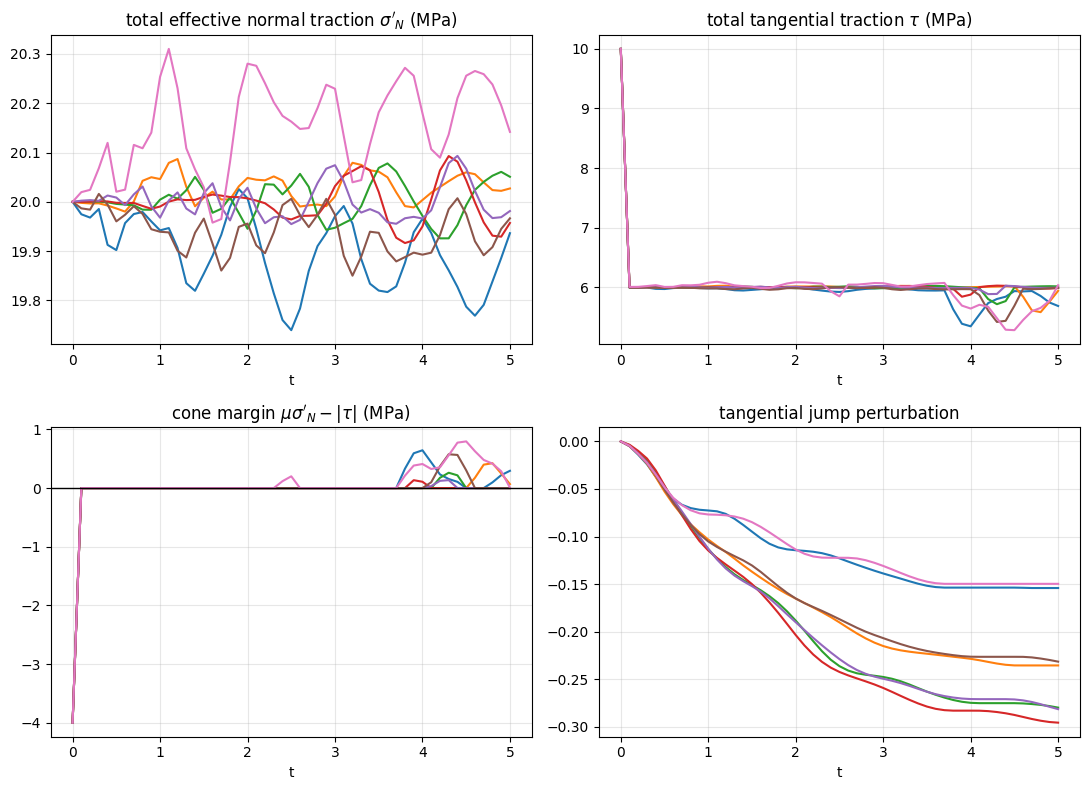

final min cone margin MPa -8.881784197001252e-16
final max |cone margin| MPa 0.29477878826921877


In [60]:

# Plot sliding response in physical total effective traction units.
r_n = r_n_sliding
r_t = r_t_sliding
cone_margin = sliding_cone_margin

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes[0,0].plot(t_sliding, r_n)
axes[0,0].set_title(r"total effective normal traction $\sigma'_N$ (MPa)")
axes[0,0].set_xlabel('t')
axes[0,0].grid(True, alpha=0.3)
axes[0,1].plot(t_sliding, r_t)
axes[0,1].set_title(r"total tangential traction $\tau$ (MPa)")
axes[0,1].set_xlabel('t')
axes[0,1].grid(True, alpha=0.3)
axes[1,0].plot(t_sliding, cone_margin)
axes[1,0].axhline(0, color='k', lw=1)
axes[1,0].set_title(r"cone margin $\mu\sigma'_N-|\tau|$ (MPa)")
axes[1,0].set_xlabel('t')
axes[1,0].grid(True, alpha=0.3)
axes[1,1].plot(t_sliding, sliding_slip)
axes[1,1].set_title(r"tangential jump perturbation")
axes[1,1].set_xlabel('t')
axes[1,1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("final min cone margin MPa", cone_margin[-1].min())
print("final max |cone margin| MPa", np.max(np.abs(cone_margin[-1])))


### 10a. Normal-Jump Diagnostic

The dashboard deformation scale is only a visualization multiplier.  The contact constraint should be checked directly from the transformed normal jump `[[u_n]]`, which is `sliding_gap` below.

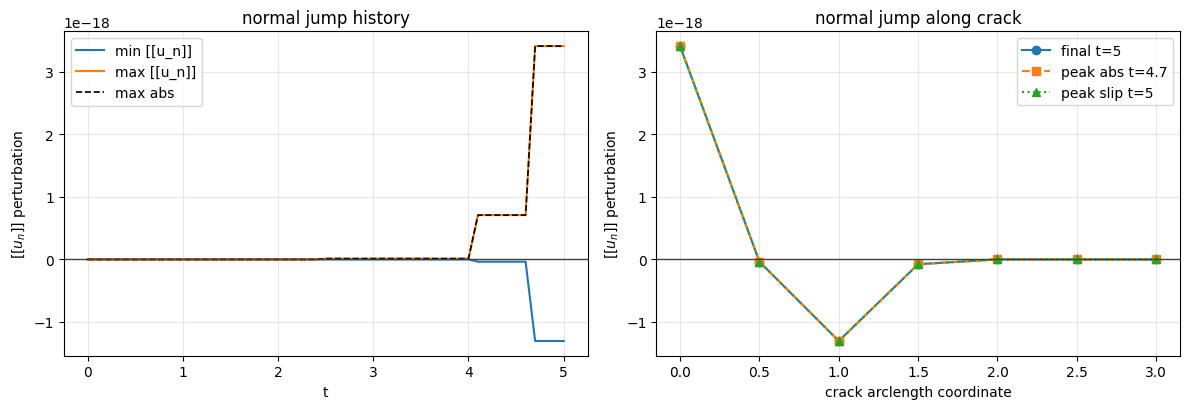

normal jump min       : -1.304046e-18
normal jump max       : 3.410973e-18
normal jump max abs   : 3.410973e-18
normal jump at final  : 3.410973e-18


In [61]:
# Direct contact-space normal jump diagnostic.  This is the quantity that
# should stay at zero for the closed sliding benchmark.
normal_jump = np.asarray(sliding_gap, dtype=float)
normal_jump_min = np.min(normal_jump, axis=1)
normal_jump_max = np.max(normal_jump, axis=1)
normal_jump_abs = np.max(np.abs(normal_jump), axis=1)

lambda_coords_s = np.asarray(
    getattr(poro_s, '_nodal_interface_info', {}).get('lambda_coords', np.zeros((2, n_c_s))),
    dtype=float,
)
if lambda_coords_s.ndim == 2 and lambda_coords_s.shape[1] == n_c_s:
    interface_xy_s = np.asarray(lambda_coords_s[:2, :].T, dtype=float)
else:
    interface_xy_s = np.column_stack([np.arange(n_c_s, dtype=float), np.zeros(n_c_s)])

centered_xy_s = interface_xy_s - interface_xy_s.mean(axis=0, keepdims=True)
if n_c_s > 1:
    _u_s, _singular_s, vh_s = np.linalg.svd(centered_xy_s, full_matrices=False)
    interface_s_raw = centered_xy_s @ vh_s[0]
else:
    interface_s_raw = np.zeros(n_c_s)
interface_order_s = np.argsort(interface_s_raw)
interface_s = np.asarray(interface_s_raw[interface_order_s], dtype=float)
if interface_s.size:
    interface_s -= interface_s[0]

peak_jump_idx = int(np.argmax(normal_jump_abs))
peak_slip_idx = int(np.argmax(np.max(np.abs(sliding_slip), axis=1)))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].plot(t_sliding, normal_jump_min, label='min [[u_n]]')
axes[0].plot(t_sliding, normal_jump_max, label='max [[u_n]]')
axes[0].plot(t_sliding, normal_jump_abs, 'k--', lw=1.2, label='max abs')
axes[0].axhline(0.0, color='0.25', lw=1.0)
axes[0].set_title('normal jump history')
axes[0].set_xlabel('t')
axes[0].set_ylabel(r'$[[u_n]]$ perturbation')
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc='best')

axes[1].plot(interface_s, normal_jump[-1, interface_order_s], 'o-', label=f'final t={t_sliding[-1]:.3g}')
axes[1].plot(interface_s, normal_jump[peak_jump_idx, interface_order_s], 's--', label=f'peak abs t={t_sliding[peak_jump_idx]:.3g}')
if peak_slip_idx != peak_jump_idx:
    axes[1].plot(interface_s, normal_jump[peak_slip_idx, interface_order_s], '^:', label=f'peak slip t={t_sliding[peak_slip_idx]:.3g}')
axes[1].axhline(0.0, color='0.25', lw=1.0)
axes[1].set_title('normal jump along crack')
axes[1].set_xlabel('crack arclength coordinate')
axes[1].set_ylabel(r'$[[u_n]]$ perturbation')
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc='best')

plt.tight_layout()
plt.show()

print(f"normal jump min       : {normal_jump.min():.6e}")
print(f"normal jump max       : {normal_jump.max():.6e}")
print(f"normal jump max abs   : {normal_jump_abs.max():.6e}")
print(f"normal jump at final  : {normal_jump_abs[-1]:.6e}")


### 10b. Dashboard — Sliding

Full-field perturbation contours.  Expect visible displacement discontinuity at the crack
and stress redistribution near the crack tips.

In [62]:
z_sliding = y_sliding[:, :n_base_s]

fields_sliding = poro_s.sol_to_fields_dict_with_dimensions(
    np.asarray(t_sliding),
    z_sliding.T,
    use_taylor_correction=False,
    constrained_l2=False,
)
fields_sliding['y_raw'] = z_sliding.T
fields_sliding['t_raw'] = np.asarray(t_sliding)

dashboard_sliding = CGPoroelasticDashboard(poro_s, fields_sliding, levels=40, deform_scale=0.0)
dashboard_sliding.show_surrogate_geom = False
if hasattr(dashboard_sliding, 'show_surrogate_geom_widget'):
    dashboard_sliding.show_surrogate_geom_widget.value = False
dashboard_sliding.show()

### 10c. Dashboard Geometry Audit

This plot reconstructs the same deformed plus/minus crack-face vertices that the dashboard uses.  It separates their relative motion into normal and tangential components, so apparent overlap from tangential sliding is not confused with normal penetration.

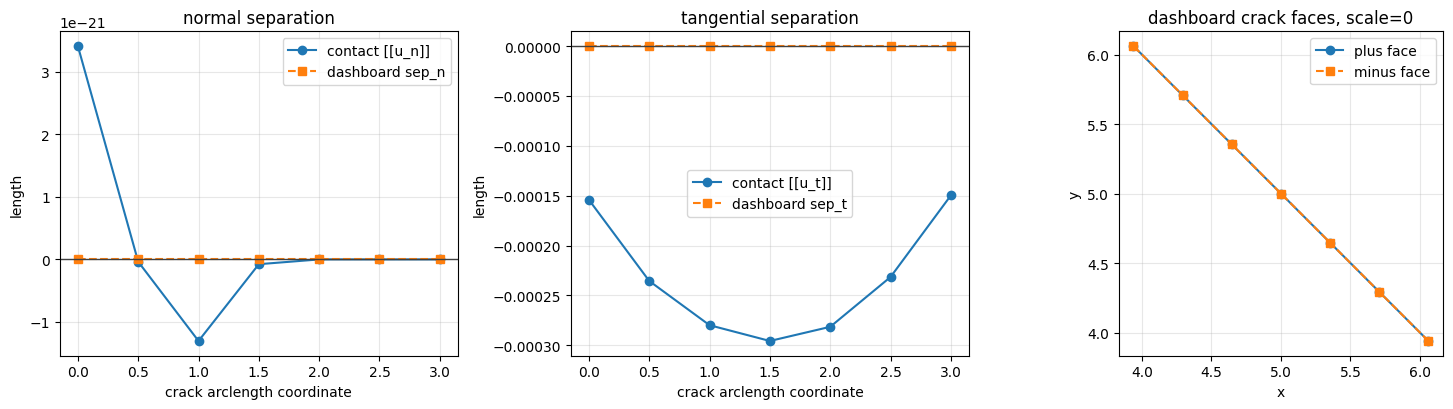

deform scale used                    : 0
max |contact normal jump|            : 3.410973e-21
max |dashboard normal sep / scale|   : 0.000000e+00
max |contact tangential jump|        : 2.957253e-04
max |dashboard tangential sep / scale|: 0.000000e+00


In [63]:
def plot_dashboard_crack_geometry_audit(tid=-1, deform_scale=None):
    if deform_scale is None:
        deform_scale = getattr(dashboard_sliding, 'deform_scale', 0.0)
        widget = getattr(dashboard_sliding, 'deform_scale_widget', None)
        if widget is not None:
            deform_scale = float(widget.value)

    intf = getattr(poro_s, '_nodal_interface_info', {})
    plus_idx = np.asarray(intf.get('lambda_to_vert_plus', []), dtype=int)
    minus_idx = np.asarray(intf.get('lambda_to_vert_minus', []), dtype=int)
    if plus_idx.size != n_c_s or minus_idx.size != n_c_s:
        raise RuntimeError('Interface plus/minus vertex maps are not available for the dashboard audit.')

    normals = np.asarray(getattr(poro_s, 'interface_normals', np.zeros((n_c_s, 2))), dtype=float)[:n_c_s]
    tangents = np.column_stack([-normals[:, 1], normals[:, 0]])

    plot_mesh = getattr(dashboard_sliding, 'mesh', poro_s.mesh)
    _, U_scale, *_ = poro_s.get_scales()
    t_idx = int(tid if tid >= 0 else len(t_sliding) + tid)
    _p_coeff, u_coeff, _lambdas = poro_s.split_solution(y_sliding[t_idx, :n_base_s])
    ux_coeff, uy_coeff = poro_s.bu_split(u_coeff)
    u_xy = np.column_stack([ux_coeff[:plot_mesh.nvertices], uy_coeff[:plot_mesh.nvertices]]) * U_scale

    X0 = np.asarray(plot_mesh.p[:2, :].T, dtype=float) * getattr(poro_s, 'L', 1.0)
    Xp = X0[plus_idx] + deform_scale * u_xy[plus_idx]
    Xm = X0[minus_idx] + deform_scale * u_xy[minus_idx]
    sep = Xp - Xm
    sep_n_plot = np.sum(sep * normals, axis=1)
    sep_t_plot = np.sum(sep * tangents, axis=1)

    contact_gap_dim = np.asarray(sliding_gap, dtype=float)[t_idx] * U_scale
    contact_slip_dim = sliding_slip[t_idx] * U_scale

    lambda_coords = np.asarray(intf.get('lambda_coords', X0[plus_idx].T), dtype=float)
    if lambda_coords.ndim == 2 and lambda_coords.shape[1] == n_c_s:
        interface_xy = np.asarray(lambda_coords[:2, :].T, dtype=float)
    else:
        interface_xy = X0[plus_idx]
    centered_xy = interface_xy - interface_xy.mean(axis=0, keepdims=True)
    if n_c_s > 1:
        _u, _singular, vh = np.linalg.svd(centered_xy, full_matrices=False)
        s_raw = centered_xy @ vh[0]
    else:
        s_raw = np.zeros(n_c_s)
    order = np.argsort(s_raw)
    s_plot = np.asarray(s_raw[order], dtype=float)
    if s_plot.size:
        s_plot -= s_plot[0]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
    axes[0].plot(s_plot, contact_gap_dim[order], 'o-', label='contact [[u_n]]')
    if deform_scale != 0.0:
        axes[0].plot(s_plot, (sep_n_plot / deform_scale)[order], 's--', label='dashboard sep_n / scale')
    else:
        axes[0].plot(s_plot, sep_n_plot[order], 's--', label='dashboard sep_n')
    axes[0].axhline(0.0, color='0.25', lw=1.0)
    axes[0].set_title('normal separation')
    axes[0].set_xlabel('crack arclength coordinate')
    axes[0].set_ylabel('length')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend(loc='best')

    axes[1].plot(s_plot, contact_slip_dim[order], 'o-', label='contact [[u_t]]')
    if deform_scale != 0.0:
        axes[1].plot(s_plot, (sep_t_plot / deform_scale)[order], 's--', label='dashboard sep_t / scale')
    else:
        axes[1].plot(s_plot, sep_t_plot[order], 's--', label='dashboard sep_t')
    axes[1].axhline(0.0, color='0.25', lw=1.0)
    axes[1].set_title('tangential separation')
    axes[1].set_xlabel('crack arclength coordinate')
    axes[1].set_ylabel('length')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend(loc='best')

    axes[2].plot(Xp[order, 0], Xp[order, 1], 'o-', label='plus face')
    axes[2].plot(Xm[order, 0], Xm[order, 1], 's--', label='minus face')
    stride = max(1, n_c_s // 8)
    for j in order[::stride]:
        axes[2].plot([Xp[j, 0], Xm[j, 0]], [Xp[j, 1], Xm[j, 1]], color='0.65', lw=0.8)
    axes[2].set_aspect('equal')
    axes[2].set_title(f'dashboard crack faces, scale={deform_scale:g}')
    axes[2].set_xlabel('x')
    axes[2].set_ylabel('y')
    axes[2].grid(True, alpha=0.3)
    axes[2].legend(loc='best')

    plt.tight_layout()
    plt.show()

    scaled_sep_n = sep_n_plot / deform_scale if deform_scale else sep_n_plot
    scaled_sep_t = sep_t_plot / deform_scale if deform_scale else sep_t_plot
    print(f'deform scale used                    : {deform_scale:g}')
    print(f'max |contact normal jump|            : {np.max(np.abs(contact_gap_dim)):.6e}')
    print(f'max |dashboard normal sep / scale|   : {np.max(np.abs(scaled_sep_n)):.6e}')
    print(f'max |contact tangential jump|        : {np.max(np.abs(contact_slip_dim)):.6e}')
    print(f'max |dashboard tangential sep / scale|: {np.max(np.abs(scaled_sep_t)):.6e}')


plot_dashboard_crack_geometry_audit(tid=-1)


## 11. Validation Summary

Compare the locked and sliding test results against the analytical Mohr-Coulomb prediction.
Overlay the numerical reaction data on the Mohr circle.

In [22]:

locked_result = 'PASS' if locked_checks_pass else 'FAIL'
sliding_result = 'PASS' if sliding_checks_pass else 'FAIL'

print("Projected Radau embedded-crack effective-traction validation summary")
print("=========================================================")
print(f"Locked θ={np.rad2deg(THETA_LOCKED):.1f}° predicted inside cone: |τ|={abs(tau_locked_val):.3f} < μσN_eff={MU*float(np.asarray(sigma_N_eff_locked)):.3f} MPa")
print(f"Sliding θ={np.rad2deg(THETA_SLIDING):.1f}° predicted outside cone: |τ|={abs(tau_sliding_val):.3f} > μσN_eff={MU*float(np.asarray(sigma_N_eff_sliding)):.3f} MPa")
print(f"Locked result: {locked_result}")
print(f"Sliding result: {sliding_result}")
print(f"Validation: {'PASS' if (locked_checks_pass and sliding_checks_pass) else 'FAIL'}")


Projected Radau embedded-crack effective-traction validation summary
Locked θ=20.0° predicted inside cone: |τ|=6.428 < μσN_eff=8.298 MPa
Sliding θ=45.0° predicted outside cone: |τ|=10.000 > μσN_eff=6.000 MPa
Locked result: PASS
Sliding result: FAIL
Validation: FAIL


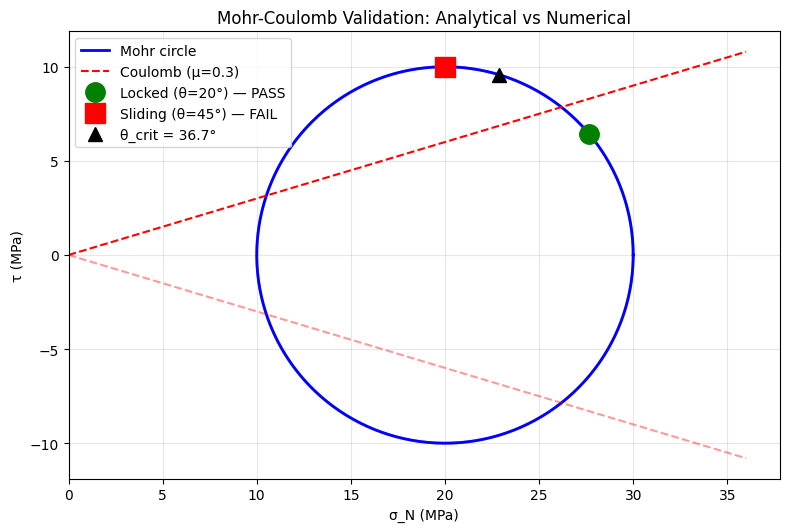

In [23]:
fig, ax = plt.subplots(figsize=(8, 6))

theta_range = np.linspace(0, np.pi, 300)
sN_range, tau_range = mohr_tractions(theta_range)
ax.plot(sN_range, tau_range, 'b-', lw=2, label='Mohr circle')
ax.plot(sN_range, -tau_range, 'b-', lw=2, alpha=0.4)

sN_env = np.linspace(0, S1 * 1.2, 100)
ax.plot(sN_env, MU * sN_env, 'r--', lw=1.5, label=f'Coulomb (μ={MU})')
ax.plot(sN_env, -MU * sN_env, 'r--', lw=1.5, alpha=0.4)

ax.plot(sigma_N_locked, tau_locked_val, 'go', ms=14, zorder=5,
        label=f'Locked (θ={np.degrees(THETA_LOCKED):.0f}°) — {locked_result}')
ax.plot(sigma_N_sliding, tau_sliding_val, 'rs', ms=14, zorder=5,
        label=f'Sliding (θ={np.degrees(THETA_SLIDING):.0f}°) — {sliding_result}')

sN_crit, tau_crit = mohr_tractions(theta_crit)
ax.plot(sN_crit, tau_crit, 'k^', ms=10, zorder=5,
        label=f'θ_crit = {np.degrees(theta_crit):.1f}°')

ax.set_xlabel('σ_N (MPa)')
ax.set_ylabel('τ (MPa)')
ax.set_title('Mohr-Coulomb Validation: Analytical vs Numerical')
ax.legend(loc='upper left')
ax.set_aspect('equal')
ax.grid(alpha=0.3)
ax.set_xlim(left=0)
plt.tight_layout()
plt.show()